In [16]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import PCGP.gpytorch_tools as gt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import os
import jax.numpy as jnp
import jax
import pandas as pd
import seaborn as sns
plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()
print(base_dir)
save_dir = os.path.join(base_dir, "graphs")
output_data_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "output_data")
input_data_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "input_data")

/home/johanna/Documents/PhD/project/github/GhostTasking


I tested "hyperhyperparameters" a) shared kernel vs no shared kernel and b) amplitude and lengthscale optimized or fixed. Results did not vary drastically so I will show results for the combination "shared kernel" and "calibration parameters optimized". I will show: a) original style MAE plot to compare if the result has gotten worse, b) all Posterior plots in one image for PIGP and GT c) an example of what i think is going wrong now compared to the earlier version d) a boxplot style MAE plot but for the old data since that's a statistical tool
extra sigmaGT 
theory: improving boxplot result
Praxis: nein tut's nicht.
Erklärung: vermutlich ill conditioned -> unstable

# Real experiment metrics

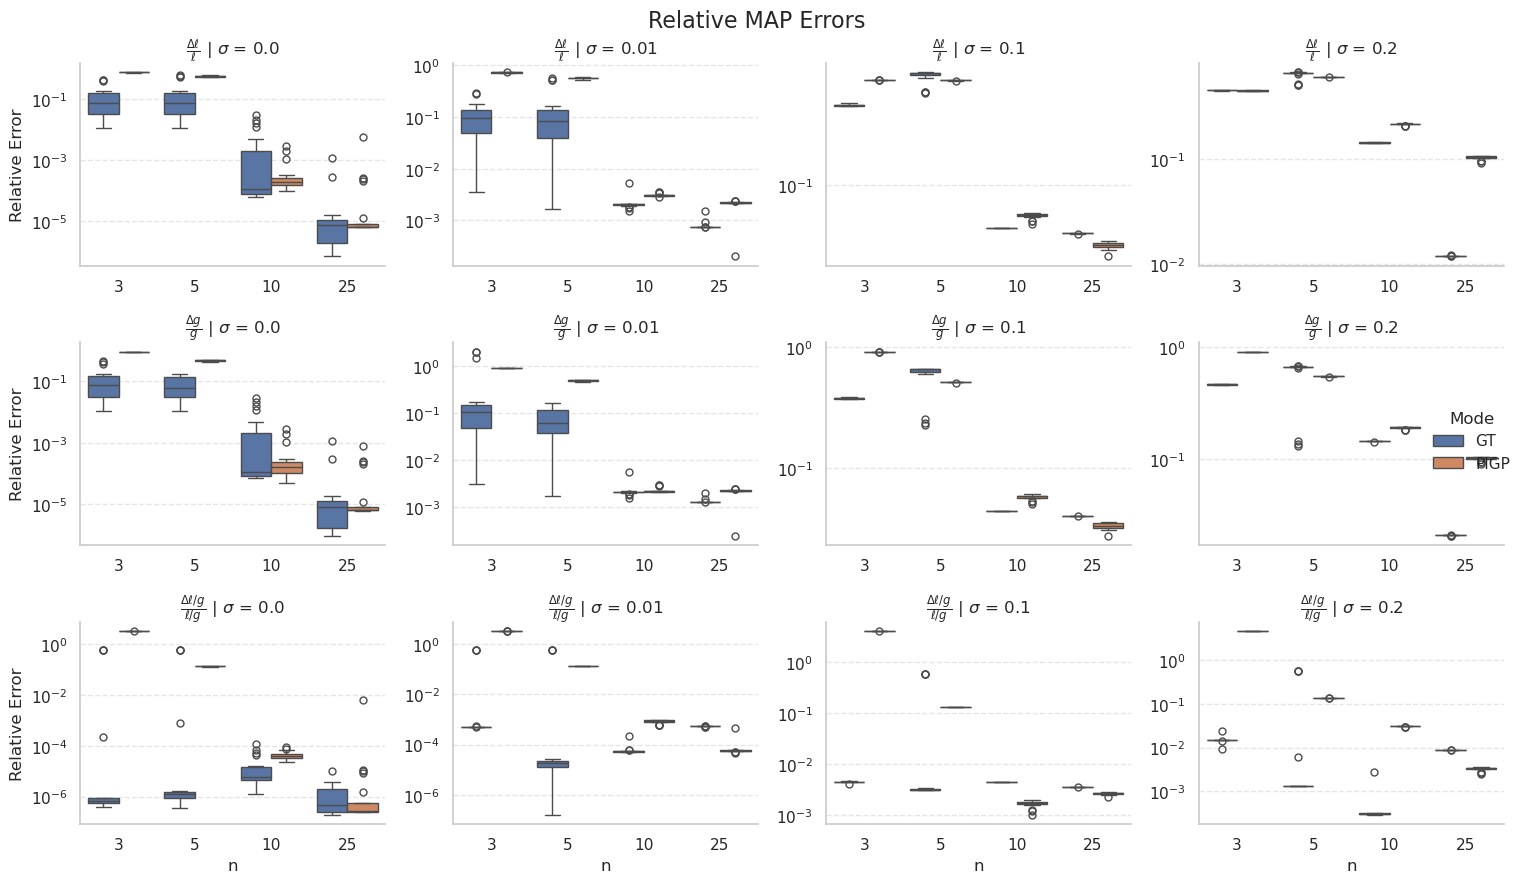

In [9]:
runs = 20

sigma_list = [0.0, 0.01, 0.1, 0.2]
n_list = [3, 5, 10, 25]
modes = ["GT", "PIGP"]

kernel_mode = "shared_kernel"
Al_mode = "withAl"
param_names = [r'$\frac{\Delta \ell}{\ell}$', r'$\frac{\Delta g}{g}$', r'$\frac{\Delta \ell/g}{\ell/g}$']


#load data
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 3, runs))

for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            for run in range(runs):
                #try:
                data_ex2 = np.load(os.path.join(output_data_ex2, kernel_mode, Al_mode, f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))#_known_sigma
                #except:
                #    data_ex2 = np.load(os.path.join(output_data_ex2,"known_u",f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
                learned_parameters = data_ex2["learned_parameters"]
                true_parameters = data_ex2["true_parameters"]
                all_AE[n_idx, sigma_idx, j, 0, run] = abs((learned_parameters[0] - true_parameters[0])/true_parameters[0])
                all_AE[n_idx, sigma_idx, j, 1, run] = abs((learned_parameters[1] - true_parameters[1])/true_parameters[1])
                all_AE[n_idx, sigma_idx, j, 2, run] = abs((learned_parameters[0] / learned_parameters[1]- true_parameters[0] / true_parameters[1])/(true_parameters[0] / true_parameters[1]))
               

#reshape
records = []
for n_idx, n in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for mode_idx, mode in enumerate(modes):
            for param_idx, param in enumerate(param_names):
                for run in range(runs):
                    records.append({
                        "n": n,
                        "sigma": sigma,
                        "mode": mode,
                        "param": param,
                        "AE": all_AE[n_idx, sigma_idx, mode_idx, param_idx, run]})

df = pd.DataFrame.from_records(records)

# categorical ordering 
df["n"] = pd.Categorical(df["n"], categories=n_list, ordered=True)
df["sigma"] = pd.Categorical(df["sigma"], categories=sigma_list, ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=modes, ordered=True)
df["param"] = pd.Categorical(df["param"], categories=param_names, ordered=True)

#plotting
sns.set(style="whitegrid")

g = sns.catplot(
    data=df,
    x="n",
    y="AE",
    hue="mode",          # ← GT vs PIGP side-by-side
    col="sigma",         # ← separate panels per sigma
    row="param",
    kind="box",
    #whis = 50,
    height=3,
    aspect=1.2,
    sharey=False,
    showfliers=True,
    dodge=True
)

#formatting
for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
   
    ax.tick_params(labelbottom=True)
    ax.set_xticks(range(len(n_list)))
    ax.set_xticklabels(n_list)

g.set_axis_labels("n", "Relative Error")
g.set_titles(row_template="{row_name}", col_template=r"$\sigma$ = {col_name}")
g._legend.set_title("Mode")
g.figure.suptitle("Relative MAP Errors", fontsize=16)
g.figure.tight_layout()
g.figure.subplots_adjust(top=0.92)


#plt.savefig(os.path.join(save_dir, "Ex2_metric.pdf"),bbox_inches='tight' )

# grid based posteriors

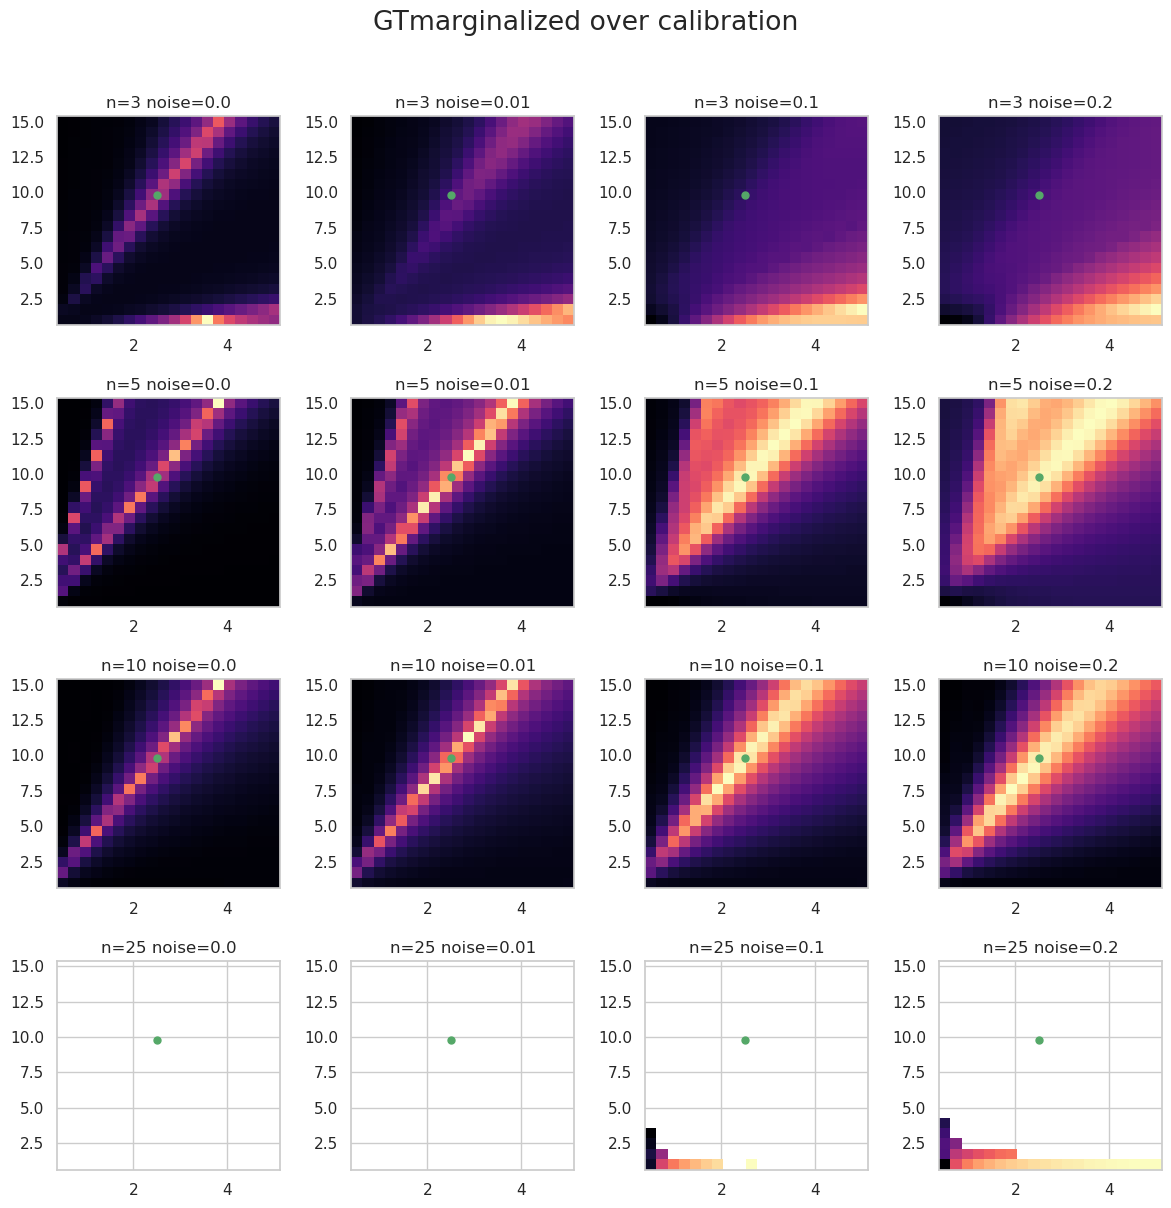

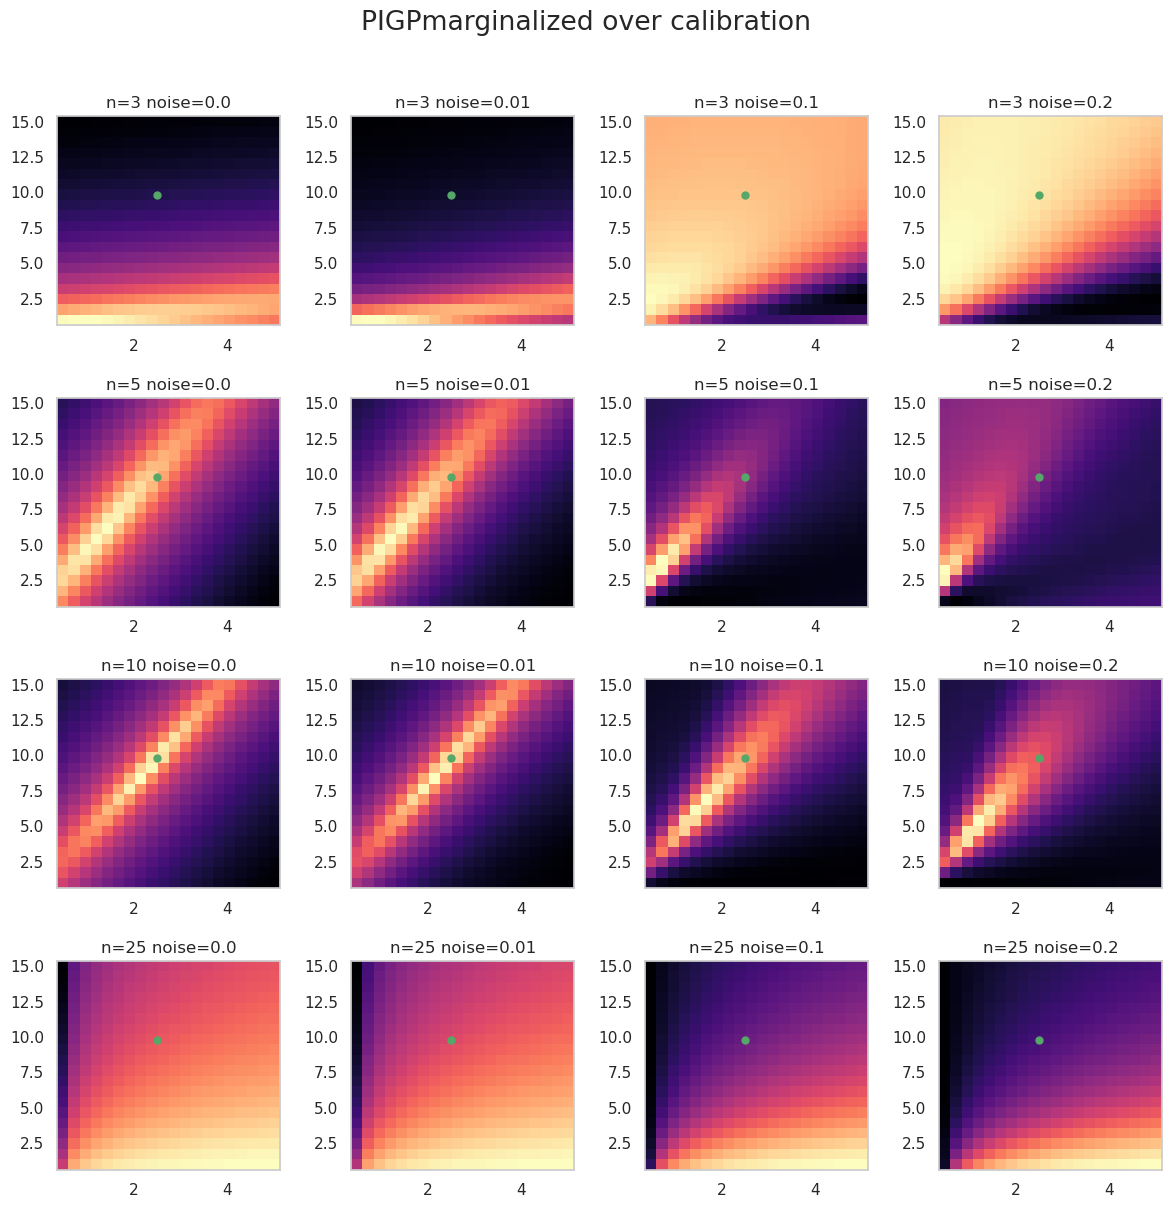

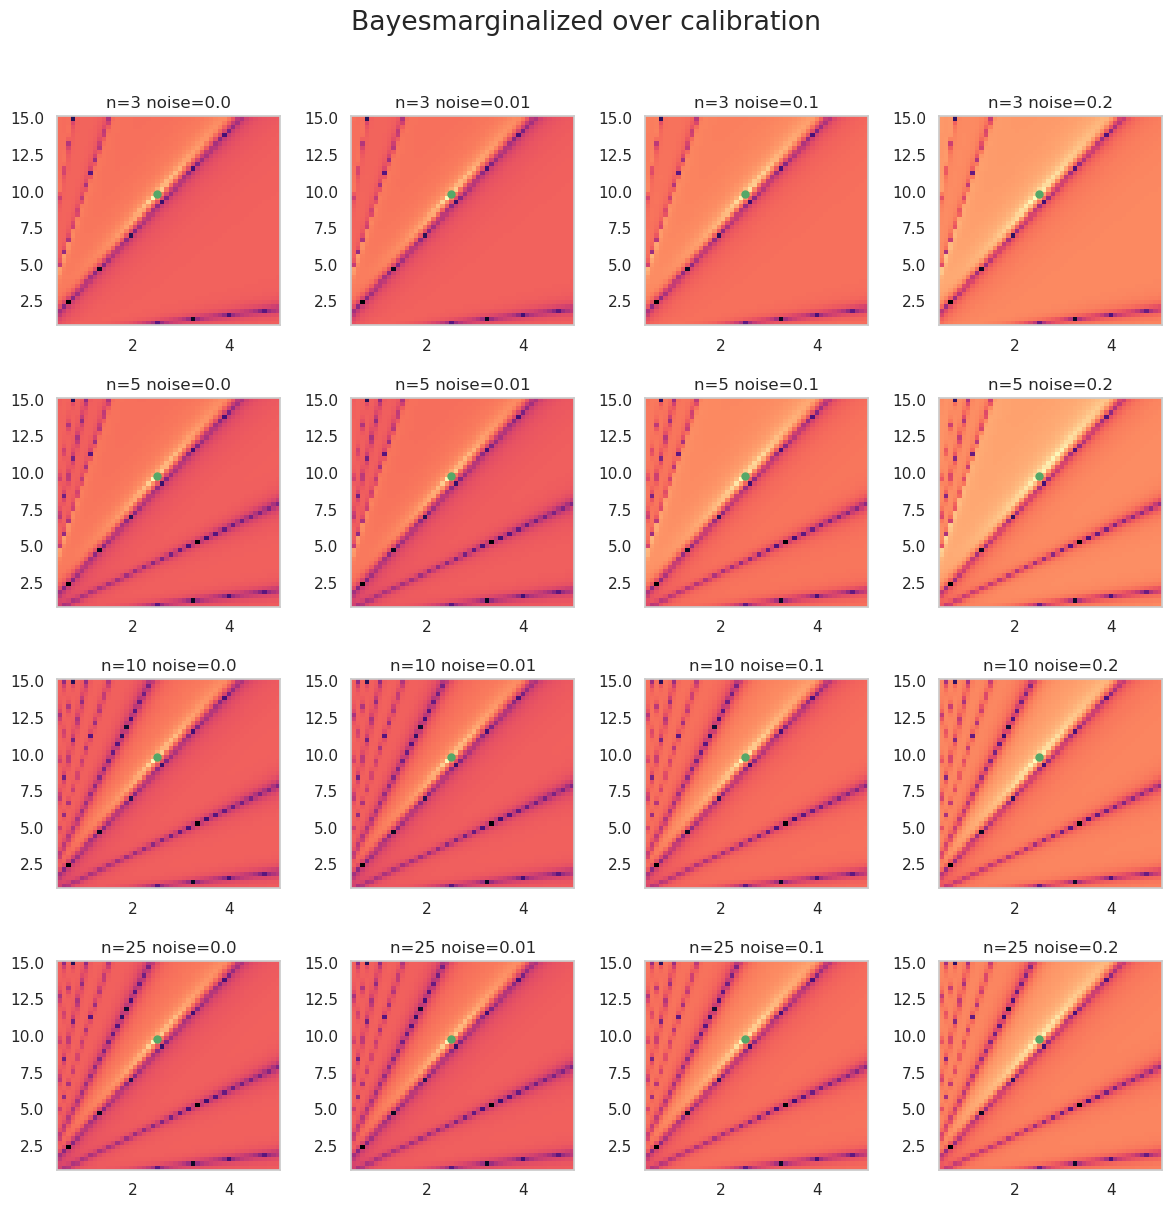

In [17]:
path_GT = os.path.join(base_dir,  "Experiment2_Tripendulum", "grid", "output")
modes = ["GT", "PIGP", "Bayes"]
sigma_list = [0.0, 0.01, 0.1, 0.2]
npoints_list = [3, 5, 10, 25]
possible_n = {"GT": 20, "PIGP":20, "Bayes":50}

plt.rcParams.update({'font.size': 16})
for mode in modes:
    fig, ax = plt.subplots(4,4, figsize = (12, 12))
    N = 400
    cmap = "jet"
    for i in range(4):
        npoints = npoints_list[i]
        for j in range(4):
            sigma = sigma_list[j]
            try:
                data_GT = np.load(os.path.join(path_GT, "%s_n%i_sigma%.2f_fulln%i.npz"%(mode, npoints, sigma, possible_n[mode])))
                for key in data_GT:
                    globals()[key] = data_GT[key]
                    #print(key)
                grids = jnp.meshgrid(l_vals, g_vals, indexing="ij")
                params_grid = jnp.stack(grids, axis=-1).reshape(-1, 4) #currently actually 30x30x30x30 grid
                order_of_parameters = {"length": 0, "g":1, "lengthscale": 2, "amplitude": 3} 
                
                #find optimum
               
                """max_idx = jnp.argmax(mll_reshaped)
                min_mll_val = mll_values[jnp.argmin(mll_values)]
                idx = jnp.unravel_index(max_idx, mll_reshaped.shape)
                best_l = l_vals[idx[0]]
                best_g = g_vals[idx[1]]
                best_ls = ls_vals[idx[2]]
                best_A = A_vals[idx[3]]
                max_mll_val = mll_reshaped[idx]"""
                #print("best values unmarginalized:", best_l, best_g, best_ls, best_A )
                #marginalisierung:
                if mode == "Bayes":
                    marginal = mll_values.reshape(possible_n[mode], possible_n[mode])
                    marginal = -jnp.log(abs(marginal))
                else:
                    mll_reshaped = mll_values.reshape(20, 20, 20, 20)
                    #if np.isnan(mll_reshaped).any():
                    #    print(mll_reshaped)
                    fixed_l = 2.5
                    fixed_g = 9.81
                    i1 = jnp.argmin(80)
                    i2   = jnp.argmin(1)
                    marginal = mll_reshaped[:,:,i1, i2]#jax.scipy.special.logsumexp(mll_reshaped, axis=(-2, -1))#np.sum(jnp.exp(mll_reshaped+jnp.min(mll_reshaped))
                    marginal = -jnp.log(abs(marginal))
                    #if np.isnan(marginal).any():
                    #    print(marginal)
                    #print(jnp.min(mll_reshaped))
                surf = ax[i,j].pcolormesh(#pcolormesh contourf
                        grids[0], grids[1], marginal,
                        cmap="magma",
                        shading="auto"
                    )
                
                ax[i,j].plot(2.5, 9.81, color = "C2", marker = "o",  markersize = 5)    
                #ax[i,j].plot(best_l, best_g, color = "r", marker = "x",  markersize = 5) 
                #ax[i,j].set_xlim(xlim)
                #ax[i,j].set_ylim(ylim)
                ax[i,j].set_title(f"n={npoints} noise={sigma}")
        
               # x = l_vals
                #ax[i,j].plot(x, 9.81/2.5*x, "g--")
            except: print("error at ", sigma, npoints)
    
    fig.suptitle(mode+"marginalized over calibration" ,y=1.01)
    plt.tight_layout()
    
    #plt.savefig(os.path.join(save_dir, "Ex2_posteriors_"+mode+"_grid.pdf"), bbox_inches='tight' )#dpi=300,

# limes of known u
theory: PIGP and GT should perform similarly

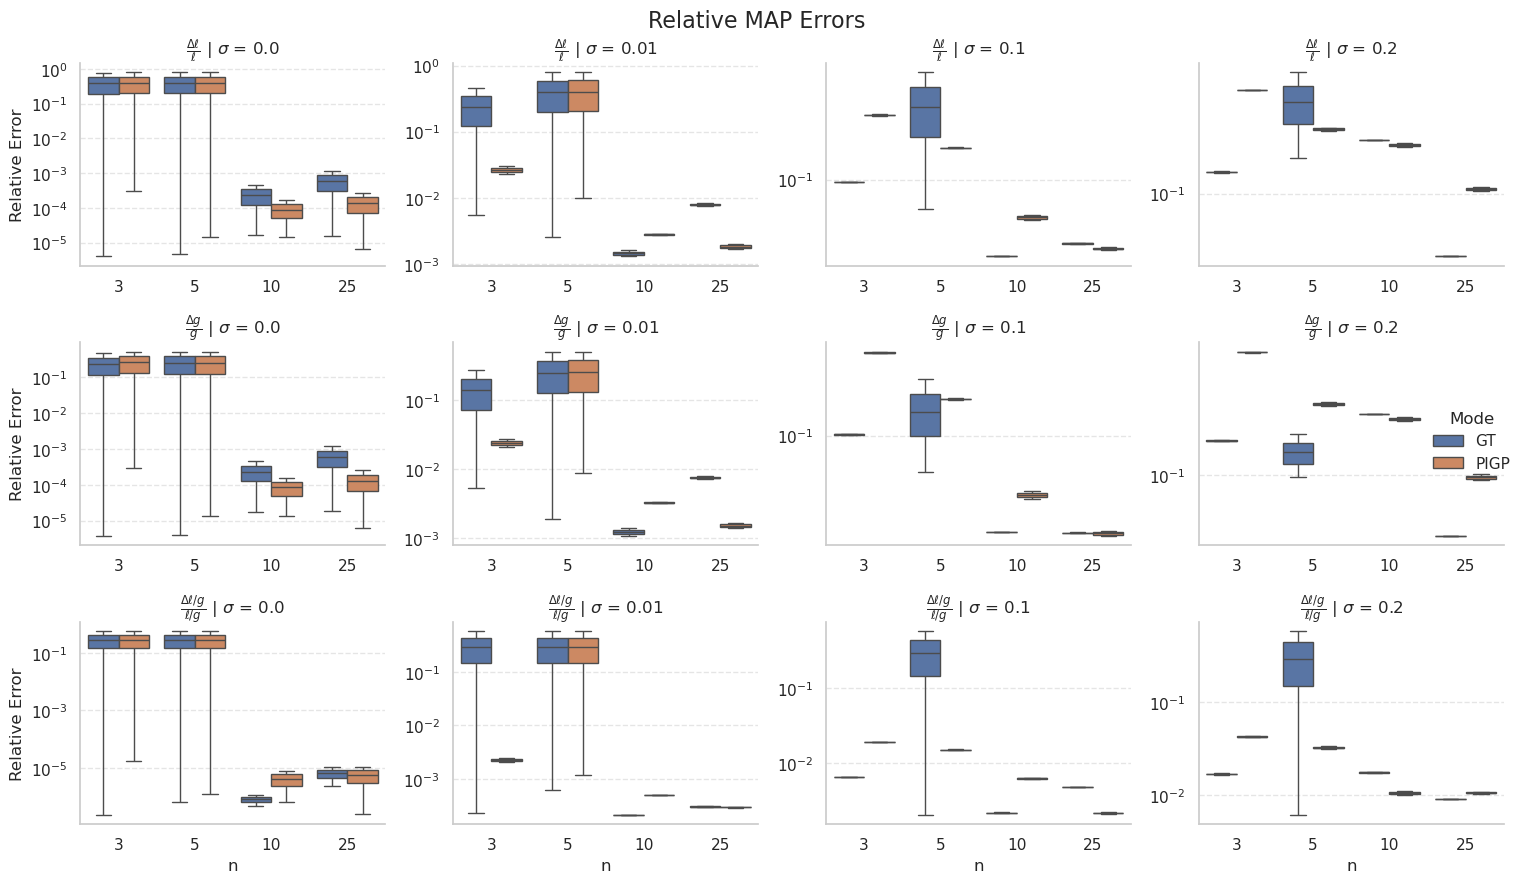

In [8]:
runs = 2
sigma_list = [0.0, 0.01, 0.1, 0.2]
n_list = [3, 5, 10, 25]
modes = ["GT", "PIGP"]
param_names = [r'$\frac{\Delta \ell}{\ell}$', r'$\frac{\Delta g}{g}$', r'$\frac{\Delta \ell/g}{\ell/g}$']

#load data
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 3, runs))

for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            for run in range(runs):
                #try:
                data_ex2 = np.load(os.path.join(output_data_ex2, "known_u", f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))#_known_sigma
                #except:
                #    data_ex2 = np.load(os.path.join(output_data_ex2,"known_u",f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
                learned_parameters = data_ex2["learned_parameters"]
                true_parameters = data_ex2["true_parameters"]
                all_AE[n_idx, sigma_idx, j, 0, run] = abs((learned_parameters[0] - true_parameters[0])/true_parameters[0])
                all_AE[n_idx, sigma_idx, j, 1, run] = abs((learned_parameters[1] - true_parameters[1])/true_parameters[1])
                all_AE[n_idx, sigma_idx, j, 2, run] = abs((learned_parameters[0] / learned_parameters[1]- true_parameters[0] / true_parameters[1])/(true_parameters[0] / true_parameters[1]))
               

#reshape
records = []
for n_idx, n in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for mode_idx, mode in enumerate(modes):
            for param_idx, param in enumerate(param_names):
                for run in range(runs):
                    records.append({
                        "n": n,
                        "sigma": sigma,
                        "mode": mode,
                        "param": param,
                        "AE": all_AE[n_idx, sigma_idx, mode_idx, param_idx, run]})

df = pd.DataFrame.from_records(records)

# categorical ordering 
df["n"] = pd.Categorical(df["n"], categories=n_list, ordered=True)
df["sigma"] = pd.Categorical(df["sigma"], categories=sigma_list, ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=modes, ordered=True)
df["param"] = pd.Categorical(df["param"], categories=param_names, ordered=True)

#plotting
sns.set(style="whitegrid")

g = sns.catplot(
    data=df,
    x="n",
    y="AE",
    hue="mode",          # ← GT vs PIGP side-by-side
    col="sigma",         # ← separate panels per sigma
    row="param",
    kind="box",
    #whis = 50,
    height=3,
    aspect=1.2,
    sharey=False,
    showfliers=True,
    dodge=True
)

#formatting
for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
   
    ax.tick_params(labelbottom=True)
    ax.set_xticks(range(len(n_list)))
    ax.set_xticklabels(n_list)

g.set_axis_labels("n", "Relative Error")
g.set_titles(row_template="{row_name}", col_template=r"$\sigma$ = {col_name}")
g._legend.set_title("Mode")
g.figure.suptitle("Relative MAP Errors", fontsize=16)
g.figure.tight_layout()
g.figure.subplots_adjust(top=0.92)


#plt.savefig(os.path.join(save_dir, "Ex2_known_u.pdf"),bbox_inches='tight' )

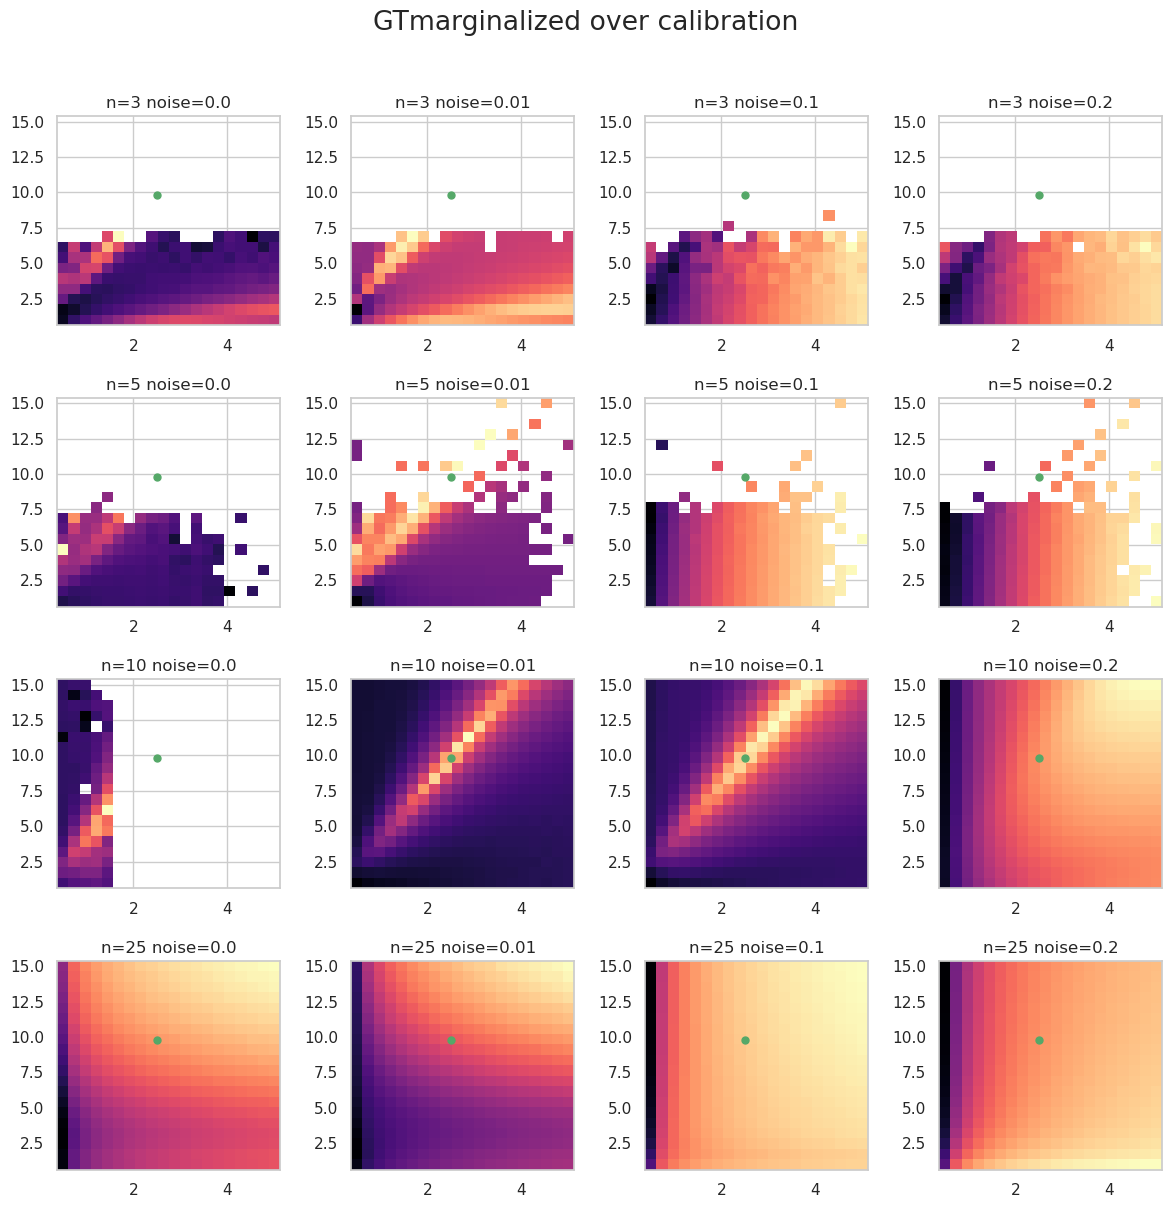

In [21]:

path_GT = os.path.join(base_dir,  "Experiment2_Tripendulum", "grid", "output")

mode = "GT"
sigma_list = [0.0, 0.01, 0.1, 0.2]
npoints_list = [3, 5, 10, 25]
possible_n = {"GT": 20, "PIGP":20, "Bayes":50}

plt.rcParams.update({'font.size': 16})

fig, ax = plt.subplots(4,4, figsize = (12, 12))
N = 400
cmap = "jet"
for i in range(4):
    npoints = npoints_list[i]
    for j in range(4):
            sigma = sigma_list[j]
        
            data_GT = np.load(os.path.join(path_GT, "known_u_known_sigma", "%s_n%i_sigma%.2f_fulln%i.npz"%(mode, npoints, sigma, possible_n[mode])))
            for key in data_GT:
                globals()[key] = data_GT[key]
               # print(key)
            grids = jnp.meshgrid(l_vals, g_vals, indexing="ij")
            params_grid = jnp.stack(grids, axis=-1).reshape(-1, 4) #currently actually 30x30x30x30 grid
            order_of_parameters = {"length": 0, "g":1, "lengthscale": 2, "amplitude": 3} 
            #print(mll_values)
            #find optimum
           
            """max_idx = jnp.argmax(mll_reshaped)
            min_mll_val = mll_values[jnp.argmin(mll_values)]
            idx = jnp.unravel_index(max_idx, mll_reshaped.shape)
            best_l = l_vals[idx[0]]
            best_g = g_vals[idx[1]]
            best_ls = ls_vals[idx[2]]
            best_A = A_vals[idx[3]]
            max_mll_val = mll_reshaped[idx]"""
            #print("best values unmarginalized:", best_l, best_g, best_ls, best_A )
            #marginalisierung:
            if mode == "Bayes":
                marginal = mll_values.reshape(possible_n[mode], possible_n[mode])
                marginal = -jnp.log(abs(marginal))
            else:
                mll_reshaped = mll_values.reshape(20, 20, 20, 20)
                #if np.isnan(mll_reshaped).any():
                #    print(mll_reshaped)
                fixed_l = 2.5
                fixed_g = 9.81
                i1 = jnp.argmin(80)
                i2   = jnp.argmin(1)
                marginal = mll_reshaped[:,:,i1, i2]#jax.scipy.special.logsumexp(mll_reshaped, axis=(-2, -1))#np.sum(jnp.exp(mll_reshaped+jnp.min(mll_reshaped))
                marginal = -jnp.log(abs(marginal))
                #if np.isnan(marginal).any():
                #    print(marginal)
                #print(jnp.min(mll_reshaped))
            surf = ax[i,j].pcolormesh(#pcolormesh contourf
                    grids[0], grids[1], marginal,
                    cmap="magma",
                    shading="auto"
                )
            
            ax[i,j].plot(2.5, 9.81, color = "C2", marker = "o",  markersize = 5)    
            #ax[i,j].plot(best_l, best_g, color = "r", marker = "x",  markersize = 5) 
            #ax[i,j].set_xlim(xlim)
            #ax[i,j].set_ylim(ylim)
            ax[i,j].set_title(f"n={npoints} noise={sigma}")
    
           # x = l_vals
            #ax[i,j].plot(x, 9.81/2.5*x, "g--")
        #except: print("error at ", sigma, npoints)

fig.suptitle(mode+"marginalized over calibration" ,y=1.01)
plt.tight_layout()
        #ax[i,j].plot(x,2.5*9.81/2.5*x, "g--")

#plt.savefig(os.path.join(save_dir, "Ex2_posteriors_"+mode+"_grid2.pdf"), bbox_inches='tight' )#dpi=300,

# Calibration parameters

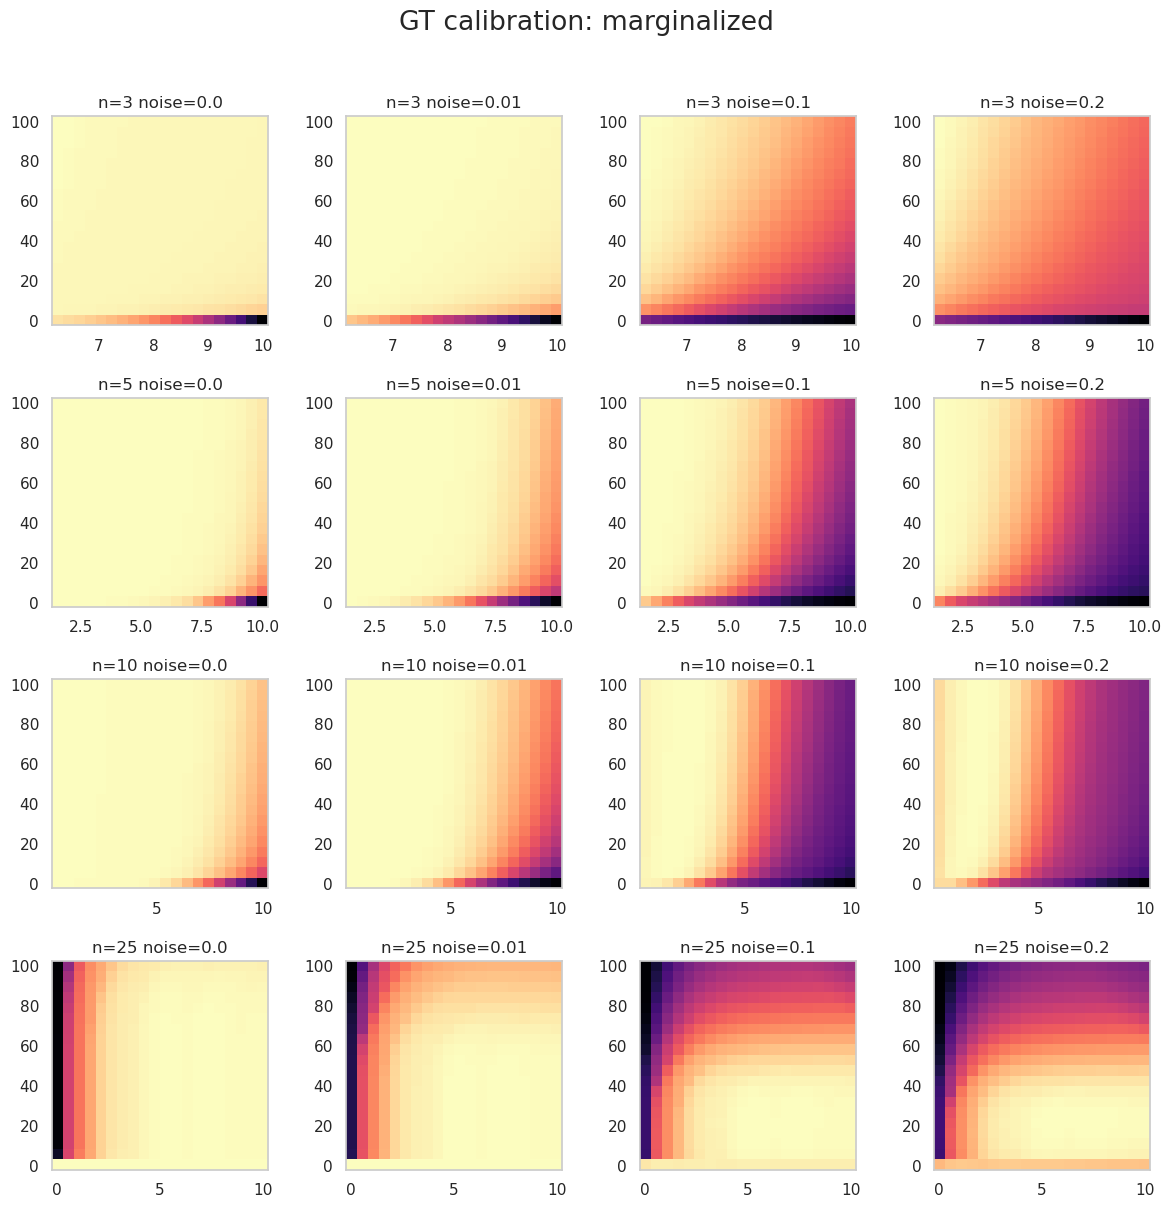

In [65]:
import jax.numpy as jnp
import jax
path_GT = os.path.join(base_dir,  "Experiment2_Tripendulum", "grid", "output")

mode = "GT"
sigma_list = [0.0, 0.01, 0.1, 0.2]
npoints_list = [3, 5, 10, 25]
possible_n = {"GT": 20, "PIGP":20, "Bayes":50}

plt.rcParams.update({'font.size': 16})

fig, ax = plt.subplots(4,4, figsize = (12, 12))
N = 400
cmap = "jet"
for i in range(4):
    npoints = npoints_list[i]
    for j in range(4):
            sigma = sigma_list[j]
    
            data_GT = np.load(os.path.join(path_GT, "%s_n%i_sigma%.2f_fulln%i.npz"%(mode, npoints, sigma, possible_n[mode])))
            for key in data_GT:
                globals()[key] = data_GT[key]
                #print(key)
            grids = jnp.meshgrid(ls_vals, A_vals, indexing="ij")
            params_grid = jnp.stack(grids, axis=-1).reshape(-1, 4) #currently actually 30x30x30x30 grid
            order_of_parameters = {"length": 0, "g":1, "lengthscale": 2, "amplitude": 3} 
            
         
            #print("best values unmarginalized:", best_l, best_g, best_ls, best_A )
            fixed_l = 2.5
            fixed_g = 9.81
            i_l = jnp.argmin(jnp.abs(l_vals - fixed_l))
            i_g   = jnp.argmin(jnp.abs(g_vals - fixed_g))
            mll_reshaped = mll_values.reshape(20, 20, 20, 20)
            #if np.isnan(mll_reshaped).any():
            #    print(mll_reshaped)
            marginal = jax.scipy.special.logsumexp(mll_reshaped, axis=(0, 1))#np.sum(jnp.exp(mll_reshaped+jnp.min(mll_reshaped))
            conditional = mll_reshaped[i_l, i_g, :,:]
            conditional = -jnp.log(abs(conditional))
            conditional = marginal
            #if np.isnan(marginal).any():
            #    print(marginal)
            #print(jnp.min(mll_reshaped))
            surf = ax[i,j].pcolormesh(#pcolormesh contourf
                grids[0], grids[1], conditional,
                cmap="magma",
                shading="auto"
            )
            
            #ax[i,j].plot(2.5, 9.81, color = "C2", marker = "o",  markersize = 5)    
            #ax[i,j].plot(best_l, best_g, color = "r", marker = "x",  markersize = 5) 
            #ax[i,j].set_xlim(xlim)
            #ax[i,j].set_ylim(ylim)
            ax[i,j].set_title(f"n={npoints} noise={sigma}")
    
           # x = l_vals
            #ax[i,j].plot(x, 9.81/2.5*x, "g--")
       
fig.suptitle(mode+" calibration: marginalized" ,y=1.01)
plt.tight_layout()
        #ax[i,j].plot(x,2.5*9.81/2.5*x, "g--")

plt.savefig(os.path.join(save_dir, "Ex2_calibration_marginalized.pdf") ,bbox_inches='tight' )#dpi=300

# Convergence

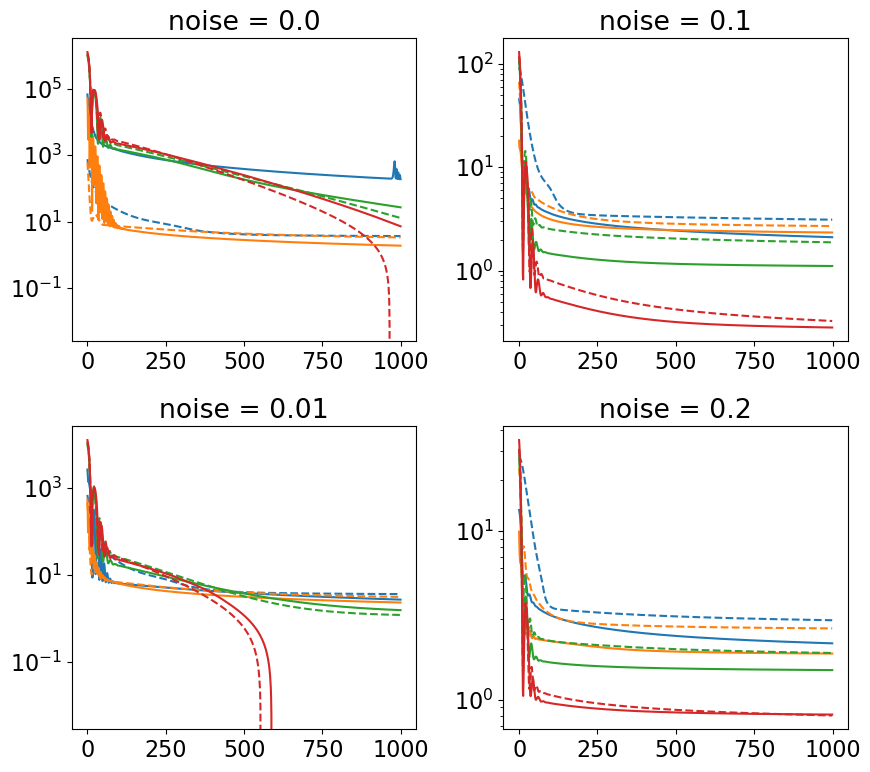

In [39]:
run = 0
sigma_list = [0.0, 0.01, 0.1, 0.2]
npoints_list = [3, 5, 10, 25]
kernel_mode = "shared_kernel"
Al_mode = "withAl"
plt.rcParams.update({'font.size': 16})
modes = ["GT", "PIGP"]
linestyle = {"GT": "-", "PIGP":"--"}
colors = ["C0","C1","C2","C3"]
fig, ax = plt.subplots(2,2, figsize = (9, 8))
for j in range(len(sigma_list)):
    sigma = sigma_list[j]
    
    for i in range(len(npoints_list)):
        npoints = npoints_list[i]
        for mode in modes:
            data_ex2 = np.load(os.path.join(
                    output_data_ex2, kernel_mode, Al_mode,
                    f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"), allow_pickle = True)
            
            loss = data_ex2["loss"]
            ax[j%2, j//2].plot(range(len(loss))[:-500], loss[:-500], linestyle[mode], color = colors[i], label = f"{mode}, n={npoints}")
    ax[j%2, j//2].set_title(f"noise = {sigma}")
    ax[j%2, j//2].set_yscale("log")

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"Ex2_convergence.pdf"), dpi = 300)
    #plt.legend()